# *Forecasting the gold price usinf the time Series*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("gold_monthly_csv.csv")
print(df.head())
df.size

      Date  Price
0  1950-01  34.73
1  1950-02  34.73
2  1950-03  34.73
3  1950-04  34.73
4  1950-05  34.73


1694

In [3]:
df.shape

(847, 2)

In [4]:
 print(f"Date range of gold prices available from - {df.loc[:,'Date'].min()} to {df.loc[:,'Date'].max()} dates")

Date range of gold prices available from - 1950-01 to 2020-07 dates


In [5]:
date = pd.date_range(start='1/1/1950',end = '8/1/2020',freq='M')
date

DatetimeIndex(['1950-01-31', '1950-02-28', '1950-03-31', '1950-04-30',
               '1950-05-31', '1950-06-30', '1950-07-31', '1950-08-31',
               '1950-09-30', '1950-10-31',
               ...
               '2019-10-31', '2019-11-30', '2019-12-31', '2020-01-31',
               '2020-02-29', '2020-03-31', '2020-04-30', '2020-05-31',
               '2020-06-30', '2020-07-31'],
              dtype='datetime64[ns]', length=847, freq='ME')

In [6]:
df['month']  = date
df.drop('Date',axis=1,inplace=True)
df = df.set_index('month')
df.head()

,Price
month,
1950-01-31,34.73
1950-02-28,34.73
1950-03-31,34.73
1950-04-30,34.73
1950-05-31,34.73


In [7]:
df.tail()

,Price
month,
2020-03-31,1593.764
2020-04-30,1680.030
2020-05-31,1715.697
2020-06-30,1734.032
2020-07-31,1840.807


In [11]:
# df['Year'] = df.index.year
# df.head()

,Price,Year
month,,
1950-01-31,34.73,1950
1950-02-28,34.73,1950
1950-03-31,34.73,1950
1950-04-30,34.73,1950
1950-05-31,34.73,1950


In [12]:
# latest_df = df[(df['Year'] >= 2015) & (df['Year'] <= 2020)]
# latest_df.head()

,Price,Year
month,,
2015-01-31,1249.333,2015
2015-02-28,1231.100,2015
2015-03-31,1180.636,2015
2015-04-30,1198.253,2015
2015-05-31,1197.684,2015


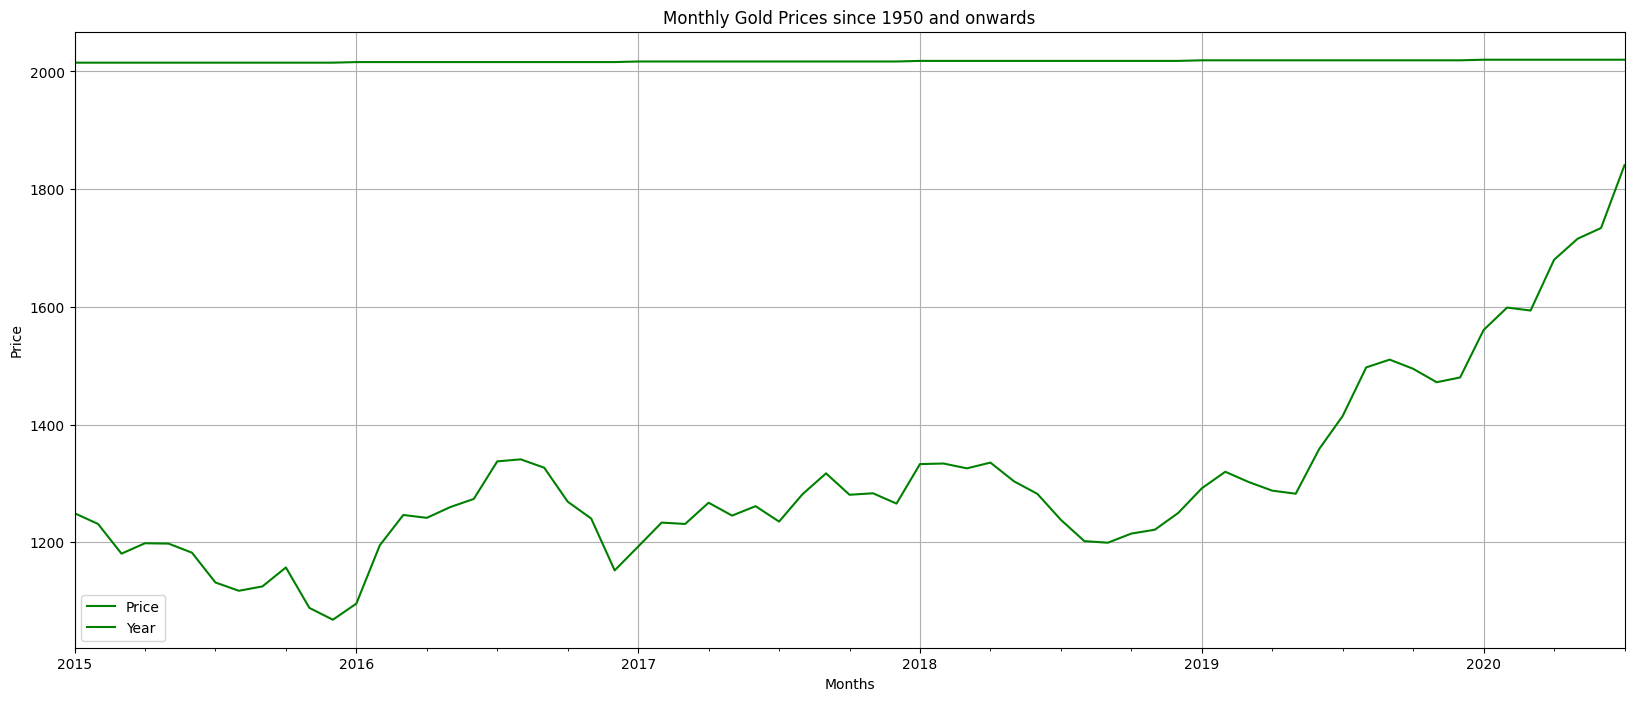

In [13]:
# latest_df.plot(figsize=(20,8),color='green')
# plt.title('Monthly Gold Prices since 1950 and onwards')
# plt.ylabel('Price')
# plt.xlabel('Months')
# plt.grid()
# plt.show()

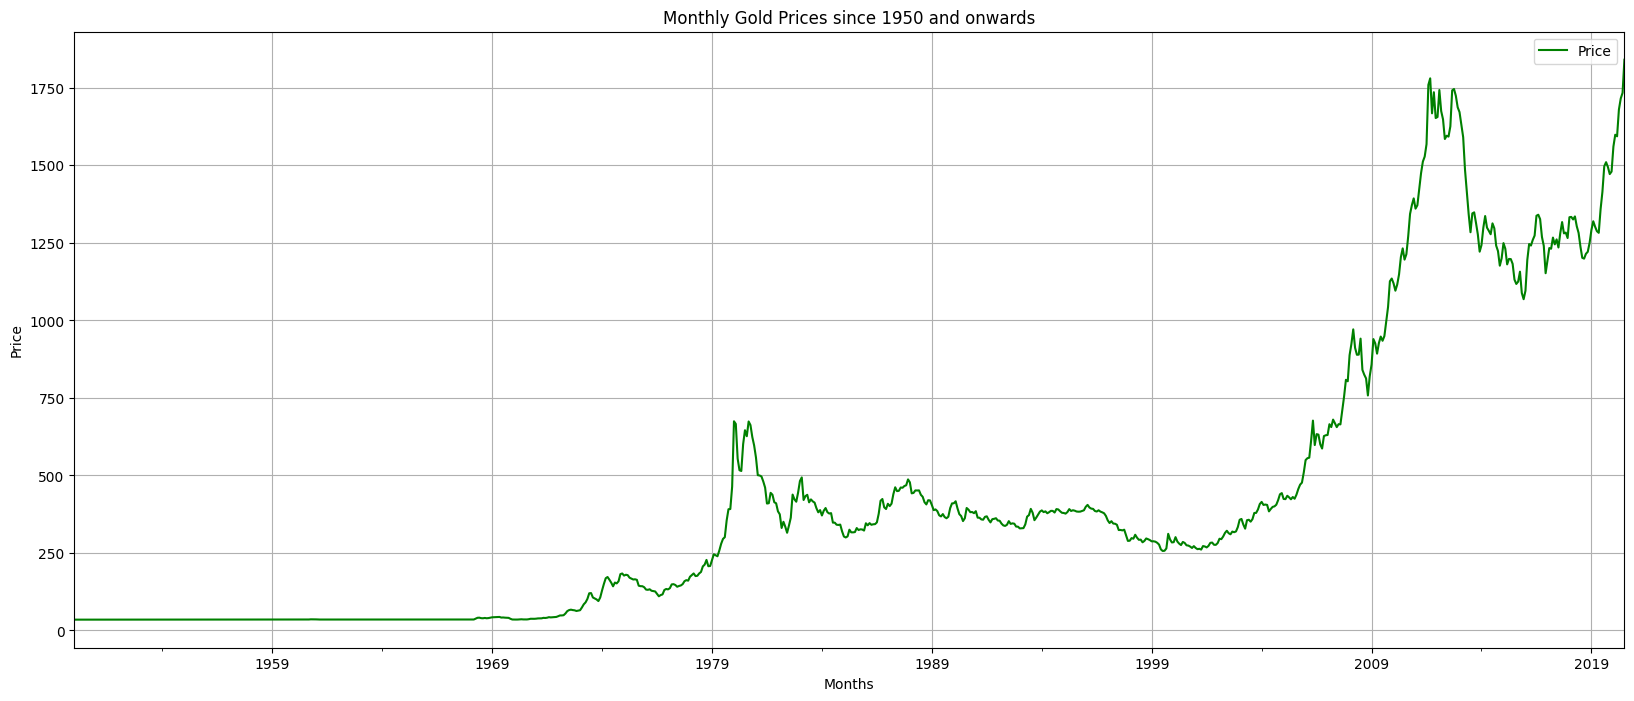

In [ ]:
df.plot(figsize=(20,8),color='green')
plt.title('Monthly Gold Prices since 1950 and onwards')
plt.ylabel('Price')
plt.xlabel('Months')
plt.grid()
plt.show()

In [ ]:
round(df.describe(),3)

,Price
count,847.000
mean,416.557
std,453.665
min,34.490
25%,35.190
50%,319.622
75%,447.029
max,1840.807


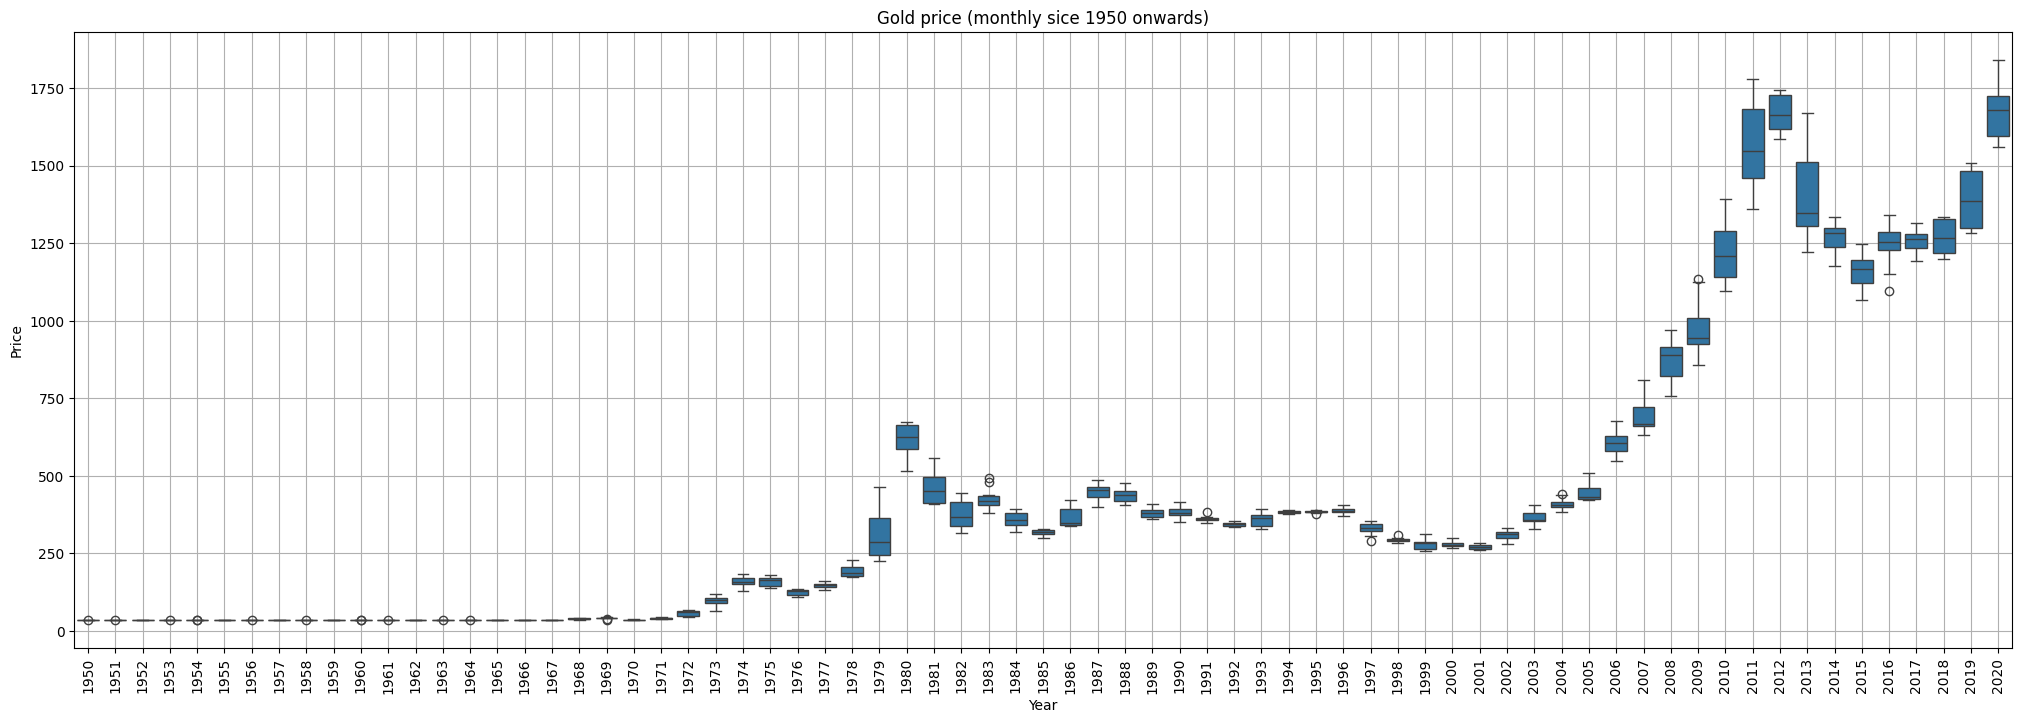

In [ ]:
_, ax = plt.subplots(figsize=(25,8))
sns.boxplot(x=df.index.year ,y = df.values[:,0],ax=ax  )
plt.title('Gold price (monthly sice 1950 onwards)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.xticks(rotation = 90)
plt.grid()

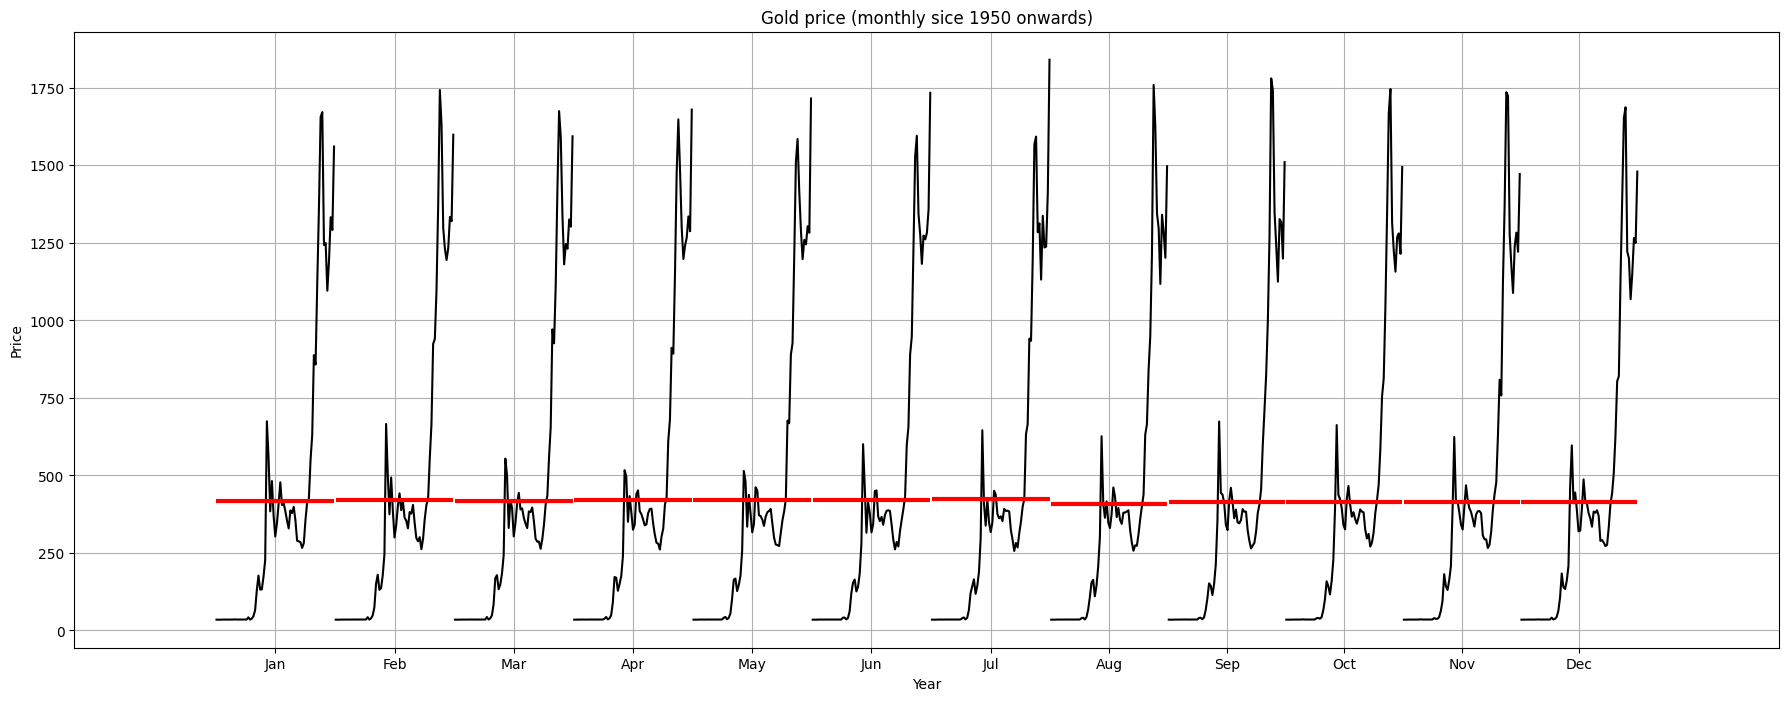

In [ ]:
from statsmodels.graphics.tsaplots import month_plot

fig,ax = plt.subplots(figsize=(22,8))
month_plot(df,ylabel='gold price',ax=ax)
plt.title('Gold price (monthly sice 1950 onwards)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()


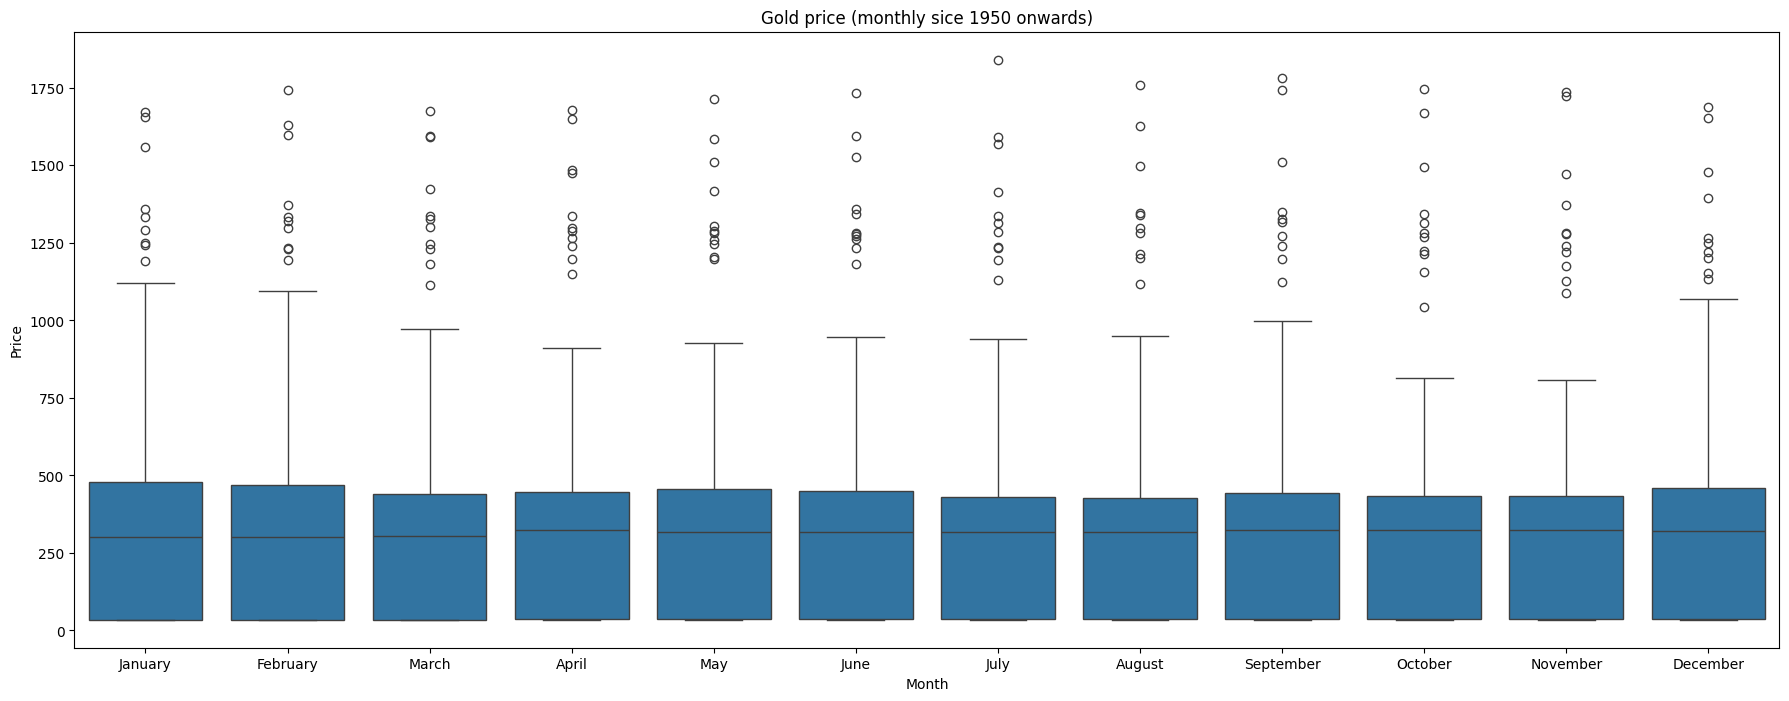

In [ ]:
_,ax = plt.subplots(figsize=(22,8))
sns.boxplot(x=df.index.month_name(),y=df.values[:,0],ax=ax)
plt.title('Gold price (monthly sice 1950 onwards)')
plt.xlabel('Month')
plt.ylabel('Price')
plt.show()

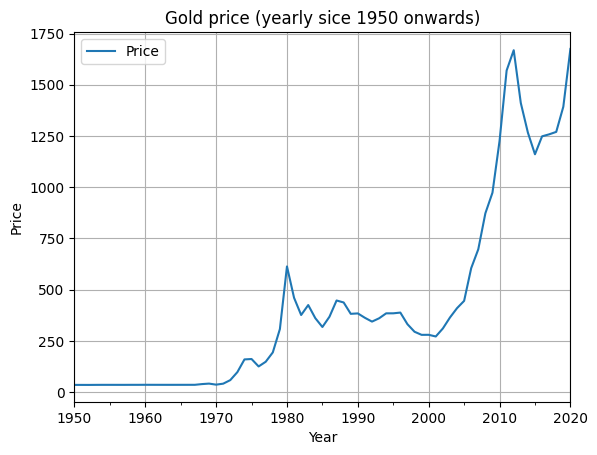

In [ ]:
df_yearly_sum = df.resample('A').mean()
df_yearly_sum.plot()
plt.title('Gold price (yearly sice 1950 onwards)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()


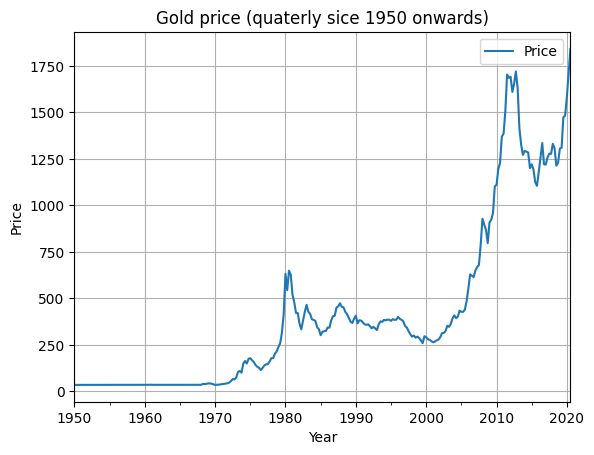

In [ ]:
df_quaterly_sum = df.resample('Q').mean()
df_quaterly_sum.plot()
plt.title('Gold price (quaterly sice 1950 onwards)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()

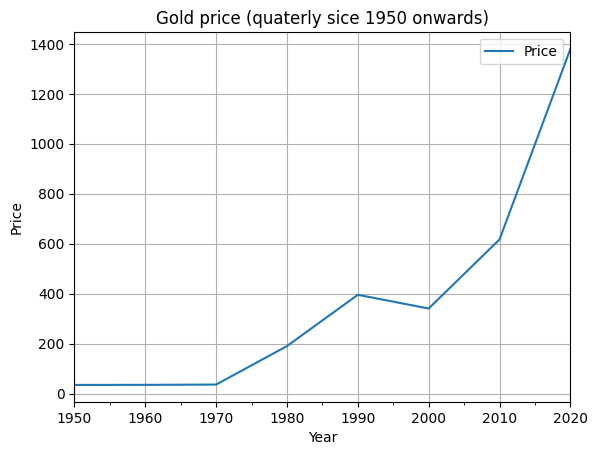

In [ ]:
df_decade_sum = df.resample('10Y').mean()
df_decade_sum.plot()
plt.title('Gold price (quaterly sice 1950 onwards)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()

In [ ]:
df_1 = df.groupby(df.index.year).mean().rename(columns={'Price':'mean'})
df_1 = df_1.merge(df.groupby(df.index.year).std().rename(columns={'Price':'std'}),left_index=True,right_index=True)
df_1['Cov_pct'] = ((df_1['std']/df_1['mean'])*100).round(2)
df_1.head()


,mean,std,Cov_pct
month,,,
1950,34.729167,0.002887,0.01
1951,34.717500,0.020057,0.06
1952,34.628333,0.117538,0.34
1953,34.879167,0.056481,0.16
1954,35.020000,0.082792,0.24


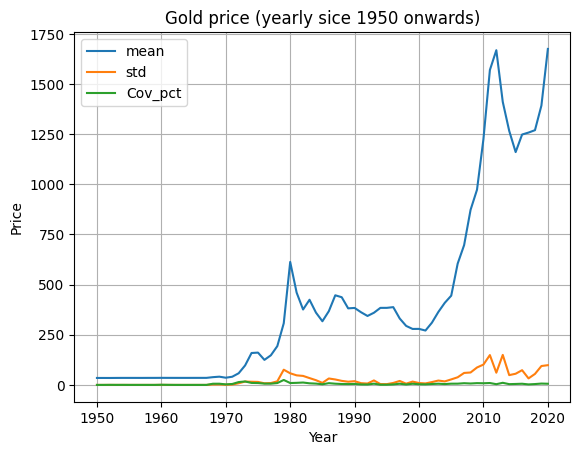

In [ ]:
df_1.plot()
plt.title('Gold price (yearly sice 1950 onwards)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()

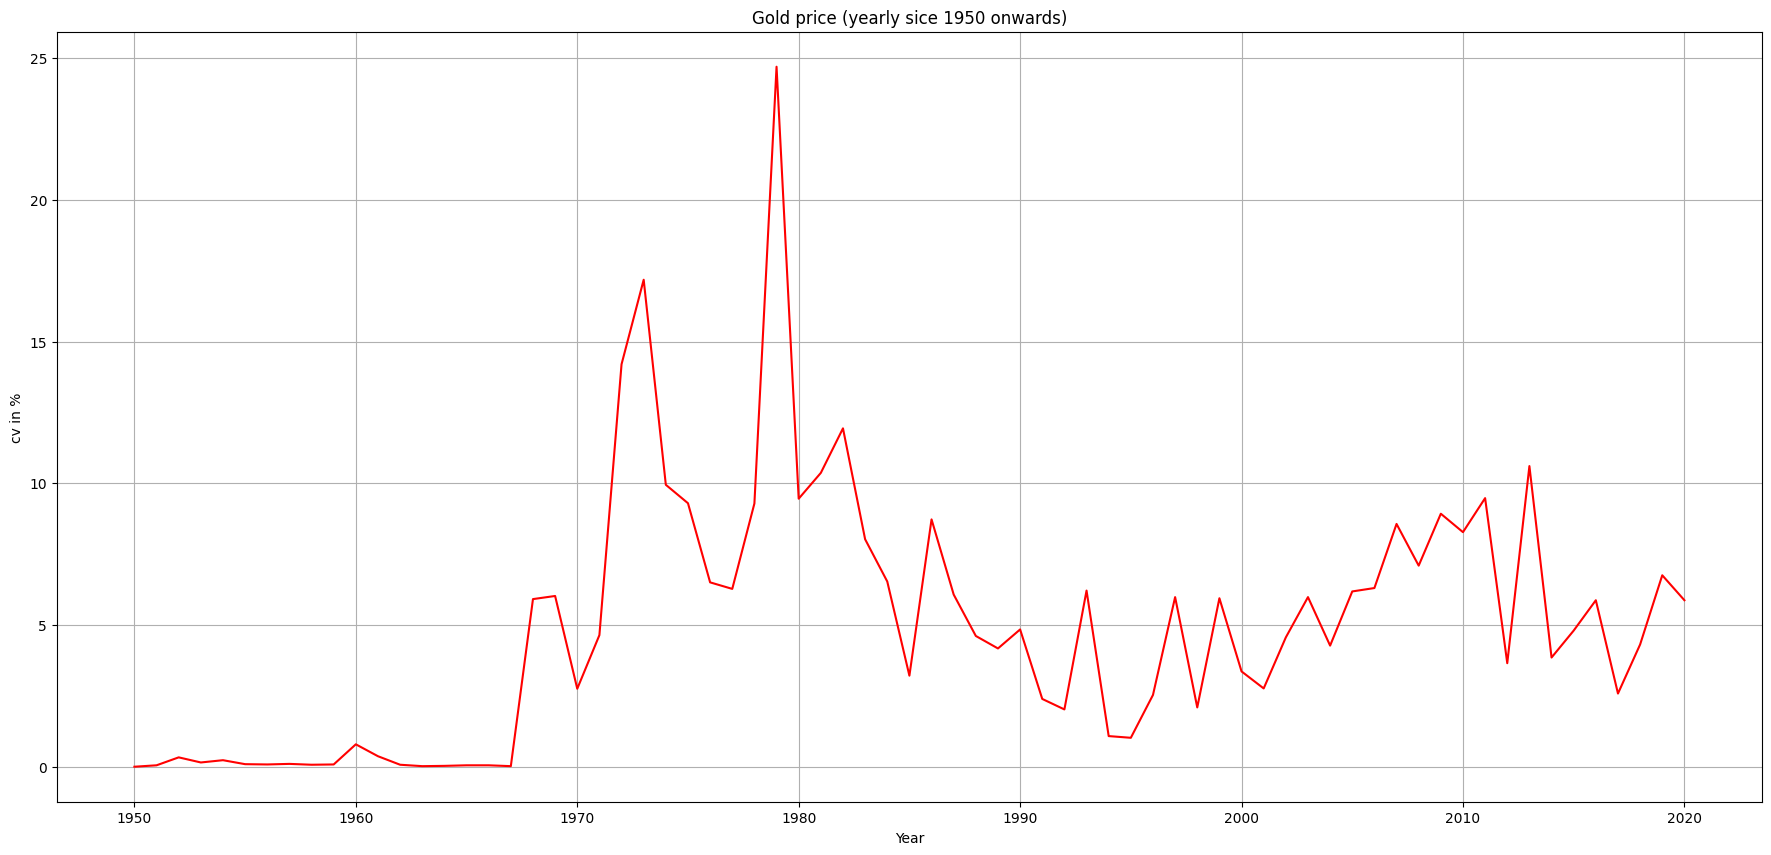

In [ ]:
fig,ax = plt.subplots(figsize=(22,10))
df_1['Cov_pct'].plot(ax=ax,color='red')
plt.title('Gold price (yearly sice 1950 onwards)')
plt.xlabel('Year')
plt.ylabel('cv in %')
plt.grid()

## Now the actual Game Starts

In [ ]:
train = df[df.index.year <= 2016]
test = df[df.index.year > 2016]

In [ ]:
print(train.shape)
print(test.shape)

(804, 1)
(43, 1)


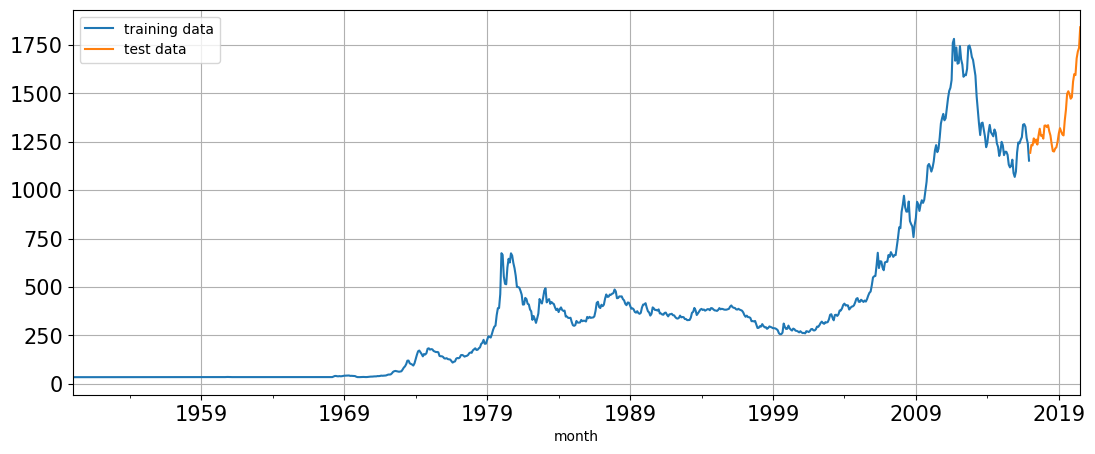

In [ ]:
train["Price"].plot(figsize=(13,5),fontsize =15)
test["Price"].plot(figsize=(13,5),fontsize =15)
plt.grid()
plt.legend(['training data','test data'])
plt.show()

In [ ]:
train_time = [i+1 for i in range(len(train))]
test_time = [i+len(train)+1 for i in range(len(test))]
len(train_time),len(test_time)

(804, 43)

In [ ]:
LR_train = train.copy()
LR_test = test.copy()

In [ ]:
LR_train['time'] = train_time
LR_test['time'] = test_time

In [ ]:
print(LR_train.head())
print(LR_test.head())

            Price  time
month                  
1950-01-31  34.73     1
1950-02-28  34.73     2
1950-03-31  34.73     3
1950-04-30  34.73     4
1950-05-31  34.73     5
               Price  time
month                     
2017-01-31  1192.648   805
2017-02-28  1233.390   806
2017-03-31  1231.063   807
2017-04-30  1267.150   808
2017-05-31  1245.250   809


In [ ]:
lr = LinearRegression()
lr.fit(LR_train[['time']],LR_train['Price'])

LinearRegression()

In [ ]:
test_predictions_model = lr.predict(LR_test[['time']])
LR_test['forecasts'] = test_predictions_model
print(LR_test.head())

               Price  time   forecasts
month                                 
2017-01-31  1192.648   805  932.348481
2017-02-28  1233.390   806  933.756200
2017-03-31  1231.063   807  935.163918
2017-04-30  1267.150   808  936.571636
2017-05-31  1245.250   809  937.979355


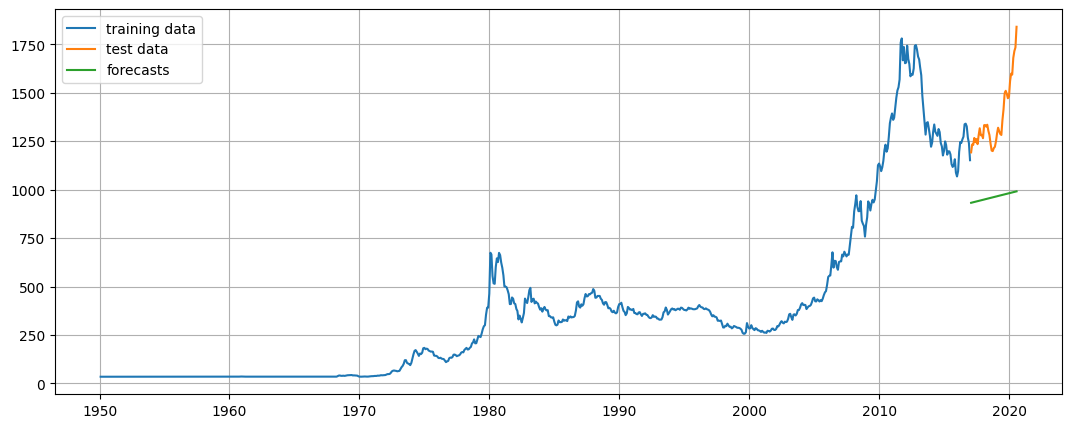

In [ ]:
plt.figure(figsize=(13,5))
plt.plot(train['Price'],label='training data')
plt.plot(test['Price'],label='test data')
plt.plot(LR_test['forecasts'],label='forecasts')
plt.legend(loc = 'best')
plt.grid()

In [ ]:
def mape(actual ,pred):
    return round(np.mean(np.abs((actual-pred)/actual))*100,2)


In [ ]:
mape_model1_test = mape(test['Price'].values,test_predictions_model)
print(f"Mape is {mape_model1_test}% ")

Mape is 28.85% 


In [ ]:
results = pd.DataFrame(
    {'Test Mape (%)':[mape_model1_test]},
    index=['Linear Regression']
    )
results


,Test Mape (%)
Linear Regression,28.85


In [ ]:
Naive_train = train.copy()
Naive_test = test.copy()

In [ ]:
Naive_test['naive'] = np.asarray(train['Price'])[len(np.asarray(train['Price']))-1]
Naive_test.head()

,Price,naive
month,,
2017-01-31,1192.648,1152.165
2017-02-28,1233.390,1152.165
2017-03-31,1231.063,1152.165
2017-04-30,1267.150,1152.165
2017-05-31,1245.250,1152.165


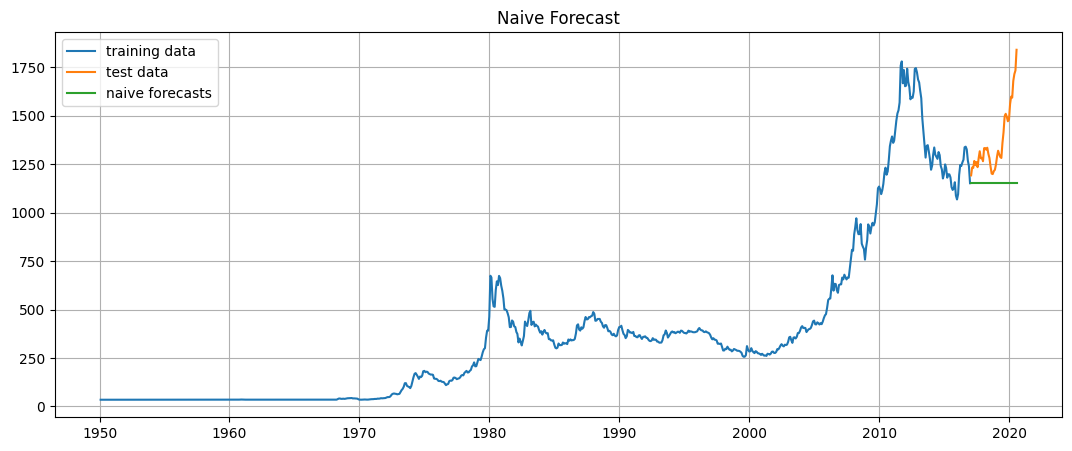

In [ ]:
plt.figure(figsize=(13,5))
plt.plot(train['Price'],label='training data')
plt.plot(test['Price'],label='test data')
plt.plot(Naive_test['naive'],label='naive forecasts')
plt.legend(loc = 'best')
plt.title('Naive Forecast')
plt.grid()

In [ ]:
mape_model2_test = mape(test['Price'].values,Naive_test['naive'].values)
print(f"Mape is {mape_model2_test}% ")

Mape is 14.64% 


In [ ]:
resultsDf2_test = pd.DataFrame(
    {'Test Mape (%)':[mape_model2_test]},
    index=['Naive Forecast']
    )
results = pd.concat([results,resultsDf2_test])
results

,Test Mape (%)
Linear Regression,28.85
Naive Forecast,14.64


In [ ]:
final_model = ExponentialSmoothing(
    df,
    trend = 'add',
    seasonal = 'add').fit(smoothing_level=0.5,
                          smoothing_trend=0.2,
                          smoothing_seasonal=0.9)


In [ ]:
Mape_final_model_test = mape(test['Price'].values,final_model.forecast(len(test)))
print(f"Mape is {Mape_final_model_test}% ")

Mape is 45.0% 


In [ ]:
predictions = final_model.forecast(len(test))


In [ ]:
pred_df = pd.DataFrame({'lower_CI': predictions - 1.96*np.std(final_model.resid,ddof=1),
                        'upper_CI': predictions + 1.96*np.std(final_model.resid,ddof=1),
                        'forecasts': predictions})
pred_df.head()

,lower_CI,upper_CI,forecasts
2020-08-31,1758.165582,1967.147739,1862.656661
2020-09-30,1681.320041,1890.302198,1785.811120
2020-10-31,1634.682948,1843.665105,1739.174027
2020-11-30,1612.571482,1821.553639,1717.062561
2020-12-31,1606.493126,1815.475283,1710.984204


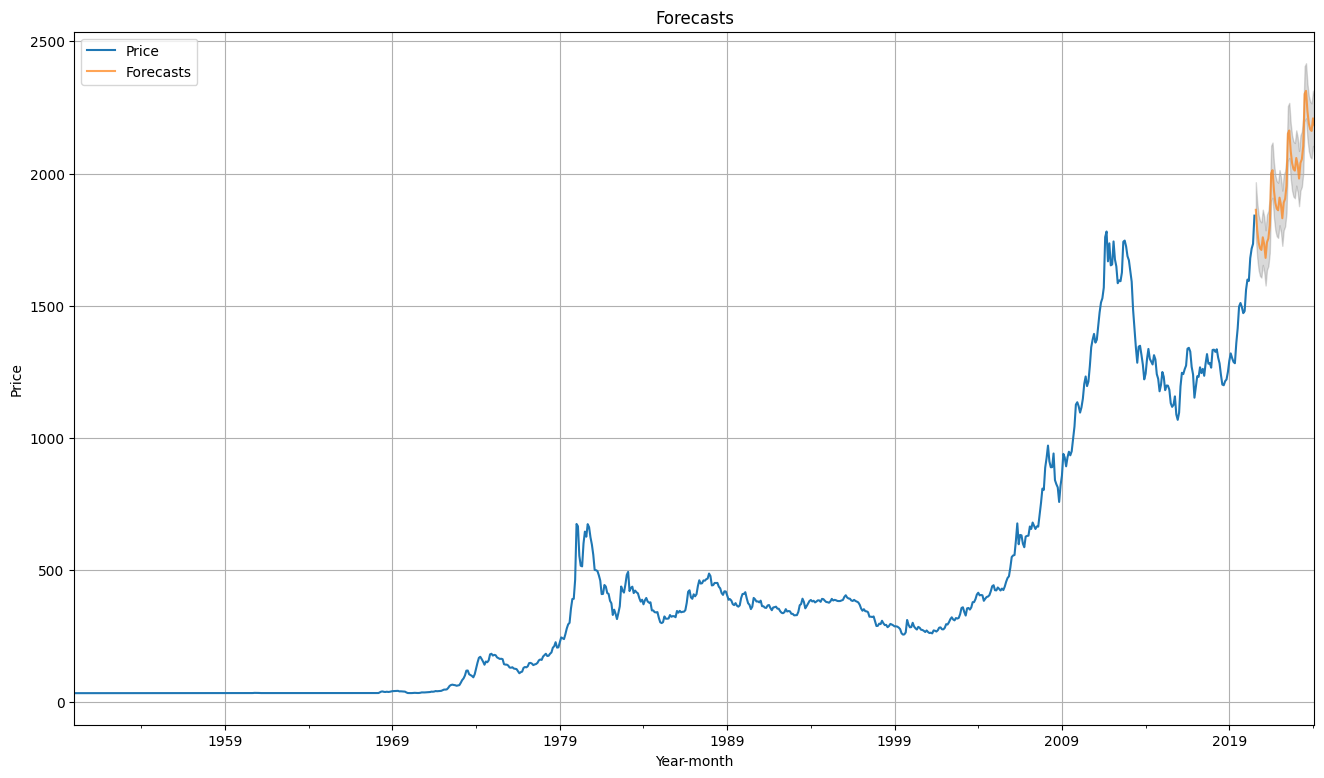

In [ ]:
axis = df.plot(label = 'Actual',figsize=(16,9))
pred_df['forecasts'].plot(ax = axis,label = 'Forecasts',alpha = 0.7)
axis.fill_between(pred_df.index,pred_df['lower_CI'],pred_df['upper_CI'],color='k',alpha=0.15)
plt.title('Forecasts')
axis.set_xlabel('Year-month')
axis.set_ylabel('Price')
plt.legend(loc = 'best')
plt.grid()
